# Stage 7: Illustrative risk grades

Input: the committed result tables `artifacts/grades_*.csv` (written by `python -m src.grades`)
and the `pd_grades` view in the DuckDB database (the frozen Stage 5 model's stored PDs,
mapped to grades). The notebook opens the database read-only and writes no artifacts.

These are **illustrative internal risk grades for this project** (D-014). They are not an
official banking methodology, not a regulatory master scale and not an underwriting decision.

Context (see `docs/decision_log.md`):
- **Development data only (D-025, D-027):** the scale is built and checked on development
  loans. This notebook, like `src/grades.py`, reads no hold-out outcome.
- **Scope (D-026):** only loans outside `credit_type = EQUI` are scored, so only they get a grade.
- **Relative PDs (D-015):** the default definition is undocumented, so grade PDs are
  meaningful relative to this dataset only.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, grades


def artifact(name: str) -> pd.DataFrame:
    return pd.read_csv(config.ARTIFACTS_DIR / f"{config.GRADES_ARTIFACT_PREFIX}{name}.csv")


con = duckdb.connect(str(config.DUCKDB_PATH), read_only=True)
dev = con.execute(
    f"SELECT g.ID, g.pd, g.grade, g.grade_rank, l.{config.TARGET_COL} "
    f"FROM {config.PD_GRADES_VIEW} AS g JOIN {config.LOANS_TABLE} AS l USING ({config.ID_COL}) "
    f"WHERE g.sample = $sample ORDER BY g.pd, g.{config.ID_COL}",
    {"sample": config.SAMPLE_DEVELOPMENT},
).df()
con.close()
y_col = config.TARGET_COL

plt.rcParams.update({
    "axes.edgecolor": config.COLOR_INK_MUTED, "axes.labelcolor": config.COLOR_INK,
    "xtick.color": config.COLOR_INK_MUTED, "ytick.color": config.COLOR_INK_MUTED,
    "axes.grid": True, "grid.color": config.COLOR_GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": config.COLOR_SURFACE, "axes.facecolor": config.COLOR_SURFACE,
})
assert len(dev) == 93_391  # in-scope development loans (D-026)
print(f"development loans graded: {len(dev):,}")

development loans graded: 93,391


## 1. Why not ten equal-count grades

D-014 first planned 10 grades. With 10 equal-count bins of the development PDs (sorted by PD,
then ID, like the SQL `NTILE` in Stage 6), the observed default rate should rise from bin to bin.

In [2]:
chunks = np.array_split(np.arange(len(dev)), 10)
dev["decile"] = np.concatenate([np.full(len(c), i + 1) for i, c in enumerate(chunks)])
deciles = dev.groupby("decile").agg(n_loans=(y_col, "size"), mean_pd=("pd", "mean"), observed_rate=(y_col, "mean"))
print(deciles.round(4).to_string())

rates = deciles["observed_rate"]
assert not grades.is_increasing(rates)
assert rates[1] > rates[2] and rates[1] > rates[3]  # the lowest-PD decile defaults MORE often
assert round(rates[1], 3) == 0.097 and round(rates[2], 3) == 0.093
assert rates.loc[1:4].between(0.09, 0.10).all()  # flat over the lowest 40% of loans
assert round(deciles.loc[1, "mean_pd"], 3) == 0.067

        n_loans  mean_pd  observed_rate
decile                                 
1          9340   0.0674         0.0972
2          9339   0.0892         0.0926
3          9339   0.1007         0.0935
4          9339   0.1107         0.0985
5          9339   0.1217         0.1035
6          9339   0.1354         0.1247
7          9339   0.1532         0.1482
8          9339   0.1775         0.1690
9          9339   0.2311         0.2499
10         9339   0.4156         0.4257


**Reading:** the observed default rate is flat at about 9-10% over the lowest four deciles,
and the lowest-PD decile (mean PD 6.7%) defaults *more* often (9.7%) than the next two (9.3%).
The model's ranking in the lower half does not show up in actual defaults. Ten equal-count
grades would fail D-014's own check (default rates rising grade by grade), so D-027 builds
the grades by merging instead.

## 2. How the grades were built (D-027)

Start from 20 equal-count PD bins; merge adjacent bins until every grade defaults
significantly more than the one below (one-sided z-test, p < 0.05), every grade holds at
least floor(5% x loans) = 4,669 loans, and there are at most 10 grades. Every merge is logged.

In [3]:
merge_log = artifact("merge_log")
print(merge_log.round(4).to_string(index=False))

assert len(merge_log) == 12
assert (merge_log["reason"].iloc[:11] == "step not significant").all()
last = merge_log.iloc[-1]
assert last["reason"] == "band below minimum share" and last["edge_removed"] == 0.276959
assert last["step_p_value"] < 0.001  # a clearly significant step, merged only for size

# the band that was too small: rounding the boundaries and tied PDs leave it one loan short
start = grades.initial_edges(dev["pd"])
start_counts = grades.band_counts(dev["pd"], dev[y_col], start)
min_loans = grades.min_grade_loans(len(dev))
print(f"\nminimum loans per grade: {min_loans:,}; starting bins: "
      f"{start_counts['n_loans'].min():,} to {start_counts['n_loans'].max():,} loans")
assert min_loans == 4_669
assert start_counts.loc[start.index(0.276959) + 1, "n_loans"] == 4_668

 merge_step  n_bands_before  edge_removed  step_p_value  lower_band_rate  upper_band_rate                   reason
          1              20        0.0706        0.9125           0.1013           0.0930     step not significant
          2              19        0.0818        0.8521           0.0971           0.0916     step not significant
          3              18        0.0956        0.6612           0.0939           0.0914     step not significant
          4              17        0.0894        0.7533           0.0953           0.0926     step not significant
          5              16        0.1107        0.6231           0.0995           0.0976     step not significant
          6              15        0.1158        0.3891           0.0985           0.1000     step not significant
          7              14        0.1007        0.3860           0.0942           0.0956     step not significant
          8              13        0.1280        0.2675           0.1069        

**Reading:** the first eleven merges remove steps that are not significant, all in the
PD range below 16.4%: they fold the flat lower half into grade A. The twelfth merge is
different: the bands at 26.6% and 31.6% default differ clearly, but the upper one holds
4,668 loans, one short of the minimum. Tied PDs and the 6-decimal rounding of the
boundaries move a few loans across bin edges, so equal-count starting bins land a few
loans either side of exactly 5%.

The number of grades therefore depends on these technical settings. The next cell
reruns the merge with two other settings, **for documentation only**. The adopted scale
keeps the pre-set settings (Bruno, D-027), so no parameter is re-chosen after seeing
the result.

In [4]:
rows = []
for label, n_bins, decimals in [("20 bins, 6 decimals (adopted)", 20, 6),
                                 ("20 bins, 9 decimals", 20, 9),
                                 ("19 bins, 6 decimals", 19, 6)]:
    edges, log = grades.merge_bands(dev["pd"], dev[y_col], grades.initial_edges(dev["pd"], n_bins, decimals))
    rows.append({"setting": label, "n_grades": len(edges) + 1,
                 "merges_for_size": int((log["reason"] == "band below minimum share").sum())})
sensitivity = pd.DataFrame(rows)
print(sensitivity.to_string(index=False))
assert sensitivity["n_grades"].tolist() == [8, 7, 10]

                      setting  n_grades  merges_for_size
20 bins, 6 decimals (adopted)         8                1
          20 bins, 9 decimals         7                2
          19 bins, 6 decimals        10                0


**Reading:** 7, 8 or 10 grades, depending on choices that have nothing to do with credit
risk. The exact number of grades is not a robust property of this model. What does hold
in every setting is the shape: one large grade covering the flat lower half, then
grades rising steadily to a small high-risk grade above 50%.

## 3. The grade scale

In [5]:
scale = artifact("scale").set_index("grade")
print(scale.round(4).to_string())

# cross-check: recomputing from the pd_grades view reproduces the artifact
recomputed = dev.groupby("grade").agg(n_loans=(y_col, "size"), observed_rate=(y_col, "mean"), mean_pd=("pd", "mean"))
assert (recomputed["n_loans"] == scale["n_loans"]).all()
assert np.allclose(recomputed["observed_rate"], scale["observed_rate"], atol=1e-6)
assert np.allclose(recomputed["mean_pd"], scale["grade_pd"], atol=1e-6)

assert list(scale.index) == list("ABCDEFGH")
assert grades.is_increasing(scale["observed_rate"])
assert scale["n_loans"].sum() == 93_391
assert round(scale.loc["A", "share"], 3) == 0.450
assert round(scale.loc["A", "pd_upper"], 4) == 0.1216
assert round(scale.loc["A", "observed_rate"], 3) == 0.096 and round(scale.loc["A", "grade_pd"], 3) == 0.095
assert round(scale.loc["H", "pd_lower"], 4) == 0.3652
assert round(scale.loc["H", "observed_rate"], 3) == 0.536 and round(scale.loc["H", "grade_pd"], 3) == 0.516
assert round(scale.loc["B", "gap"], 3) == -0.019 and scale.loc["B", "binomial_p"] < 0.001
assert round(scale.loc["F", "gap"], 3) == 0.023 and scale.loc["F", "binomial_p"] < 0.001
assert scale["gap"].abs().max() < 0.025

       grade_rank  pd_lower  pd_upper  grade_pd  n_loans  n_defaults   share  mean_pd  observed_rate     gap  step_p_value  binomial_p
grade                                                                                                                                 
A               1    0.0000    0.1216    0.0950    42029      4034.0  0.4500   0.0950         0.0960  0.0010           NaN      0.4692
B               2    0.1216    0.1352    0.1282     9341      1017.0  0.1000   0.1282         0.1089 -0.0193        0.0001      0.0000
C               3    0.1352    0.1532    0.1437     9340      1317.0  0.1000   0.1437         0.1410 -0.0027        0.0000      0.4609
D               4    0.1532    0.1769    0.1641     9327      1471.0  0.0999   0.1641         0.1577 -0.0063        0.0007      0.0990
E               5    0.1769    0.1954    0.1852     4675       821.0  0.0501   0.1852         0.1756 -0.0095        0.0035      0.0938
F               6    0.1954    0.2286    0.2108     467

**Reading:**
- **Grade A** holds 45% of loans (PD below 12.16%), with a grade PD of 9.5% against an observed
  9.6%. Pooling the flat lower half into one grade also absorbs the D-023 misfit at the
  lowest PDs (high incomes, large loans). Inside grade A the model still ranks these
  loans, but the ranking is not borne out by defaults.
- The observed default rate rises from 9.6% (A) to 53.6% (H). Every step is significant
  (largest p = 0.003, grade D to E).
- **Grade PD vs observed (in-sample, reported only):** every gap is within 2.3 pp. B is
  over-predicted by 1.9 pp, and F and H are under-predicted by 2.3 and 1.9 pp. These gaps
  are in-sample, so they are a description, not a validation result.

## 4. Out-of-fold check

The same grade boundaries applied to out-of-fold PDs: each development loan is scored by
the Stage 5 fold model that did not see it (same 5 folds and seed as the CV).

In [6]:
oof = artifact("oof_check")
by_fold = oof.pivot(index="grade", columns="sample", values="observed_rate")
print(by_fold.round(3).to_string())

for sample in by_fold.columns:
    assert grades.is_increasing(by_fold[sample]), sample
pooled = oof[oof["sample"] == "pooled"].set_index("grade")
assert pooled["n_loans"].sum() == 93_391
assert (pooled["observed_rate"] - scale["observed_rate"]).abs().max() < 0.005

sample  fold_1  fold_2  fold_3  fold_4  fold_5  pooled
grade                                                 
A        0.095   0.098   0.097   0.097   0.094   0.096
B        0.119   0.108   0.105   0.109   0.117   0.112
C        0.135   0.132   0.143   0.133   0.141   0.137
D        0.152   0.165   0.160   0.163   0.156   0.159
E        0.167   0.185   0.177   0.173   0.173   0.175
F        0.235   0.231   0.225   0.243   0.225   0.232
G        0.296   0.286   0.288   0.284   0.303   0.292
H        0.547   0.546   0.534   0.522   0.529   0.535


**Reading:** the default rate rises grade by grade on the pooled out-of-fold PDs and in
each of the 5 folds separately. The pooled rates are within 0.5 pp of the in-sample
rates. With 6 features and 93,000 loans the model hardly overfits, so the grades do not
depend on the in-sample fit.

## 5. Pre-set checks (D-027)

In [7]:
checks = artifact("checks")
print(checks.to_string(index=False))
assert (checks.loc[checks["status"] != "report", "status"] == "pass").all()
assert (checks.loc[checks["status"] == "report", "value"].astype(str) == "True").all()

                            check                 value                            rule status
         rates_increase_in_sample                  True                    must be True   pass
rates_increase_out_of_fold_pooled                  True                    must be True   pass
                  min_grade_loans                  4670 >= 4669 (floor of 0.05 x loans)   pass
                 max_step_p_value 0.0034682697770037907                          < 0.05   pass
                         n_grades                     8                           <= 10   pass
rates_increase_out_of_fold_fold_1                  True                   reported only report
rates_increase_out_of_fold_fold_2                  True                   reported only report
rates_increase_out_of_fold_fold_3                  True                   reported only report
rates_increase_out_of_fold_fold_4                  True                   reported only report
rates_increase_out_of_fold_fold_5                 

**Reading:** every pre-set check passes, and every fold is monotone.

## 6. Figure

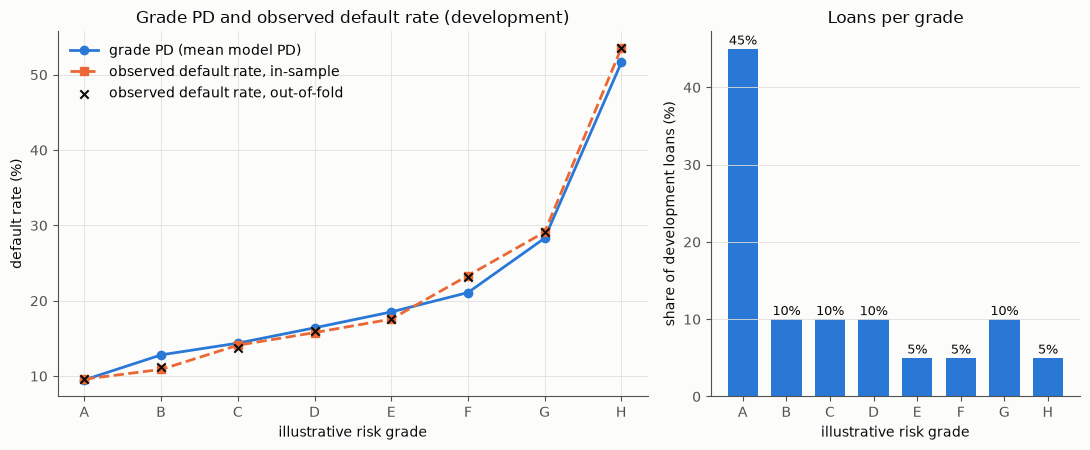

In [8]:
labels = list(scale.index)
x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.plot(x, scale["grade_pd"] * 100, color=config.COLOR_PRIMARY, linewidth=2, marker="o", label="grade PD (mean model PD)")
ax1.plot(x, scale["observed_rate"] * 100, color=config.COLOR_SECONDARY, linewidth=2, linestyle="--",
         marker="s", label="observed default rate, in-sample")
ax1.scatter(x, pooled["observed_rate"] * 100, color=config.COLOR_INK, marker="x", zorder=3,
            label="observed default rate, out-of-fold")
ax1.set_xticks(x, labels)
ax1.set_xlabel("illustrative risk grade")
ax1.set_ylabel("default rate (%)")
ax1.set_title("Grade PD and observed default rate (development)", color=config.COLOR_INK)
ax1.legend(frameon=False, loc="upper left")

ax2.bar(x, scale["share"] * 100, color=config.COLOR_PRIMARY, width=0.7)
for xi, share in zip(x, scale["share"]):
    ax2.annotate(f"{share:.0%}", (xi, share * 100), xytext=(0, 3), textcoords="offset points",
                 ha="center", color=config.COLOR_INK, fontsize=9)
ax2.set_xticks(x, labels)
ax2.set_xlabel("illustrative risk grade")
ax2.set_ylabel("share of development loans (%)")
ax2.set_title("Loans per grade", color=config.COLOR_INK)
ax2.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "12_risk_grades.png", dpi=config.FIGURE_DPI)
plt.show()

## 7. Scope and the hold-out

In [9]:
scope = artifact("scope").set_index("sample")
print(scope.to_string())
assert (scope["n_in_scope_not_graded"] == 0).all()
assert scope.loc[config.SAMPLE_DEVELOPMENT, "n_graded"] == 93_391
assert scope.loc[config.SAMPLE_HOLDOUT, "n_graded"] == 39_981
assert scope["n_out_of_scope_equi"].tolist() == [10_678, 4_620]
assert scope["n_loans"].sum() == config.EXPECTED_N_ROWS

             n_loans  n_graded  n_out_of_scope_equi  n_in_scope_not_graded
sample                                                                    
development   104069     93391                10678                      0
holdout        44601     39981                 4620                      0


**Reading:** every in-scope loan has exactly one grade; EQUI loans have none (D-026). The
39,981 hold-out loans carry a grade label, because `pd_grades` maps every stored PD,
but no hold-out outcome is used here or in `src/grades.py`.
`tests/test_grades.py` checks this by flipping every hold-out `Status` and confirming that
no Stage 7 table changes.

## 8. Conclusion

- **8 illustrative grades (A to H)**, built on development loans only, with default rates
  rising from 9.6% to 53.6%. Every step is significant, and the order holds out of fold and
  in every fold.
- **Grade A holds 45% of loans.** The model cannot rank risk below a PD of about 12%, so one
  honest grade covers that region (D-027, S4).
- **The grade count is not robust:** depending on technical settings it is 7, 8 or 10. The
  pre-set settings were kept.
- **Grade PD = mean model PD**, so the in-sample gaps (within 2.3 pp) stay visible and are not
  recalibrated away.
- **Limitations carried over:** the model lacks LTV and debt-to-income (D-017), covers only
  loans outside EQUI (D-026), and the default definition is undocumented (D-015).
- The `pd_grades` view is the input for Stage 8 (monitoring) and Stage 9 (dashboard).